# Agent Output Overview

This notebook provides a structured view of `results/logs/api_calls.jsonl`. It is useful for inspecting request volume, token usage, cost, cache behavior, and model outputs.

It works with both real Anthropic runs and offline smoke-test logs, but the summary is most meaningful when real API calls are present.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

def find_log_path() -> Path:
    candidates = [
        Path('results/logs/api_calls.jsonl'),
        Path('../results/logs/api_calls.jsonl'),
        Path('../../results/logs/api_calls.jsonl'),
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError('Could not find results/logs/api_calls.jsonl from the current notebook location.')

LOG_PATH = find_log_path()
LOG_PATH

PosixPath('/Users/louisewiljander/Documents/Projects/llm-vc-decision-textgrad/llm-vc-decision-textgrad/results/logs/api_calls.jsonl')

In [2]:
def strip_code_fences(text):
    if not isinstance(text, str):
        return ''
    cleaned = text.strip()
    if cleaned.startswith('```'):
        parts = cleaned.split('```')
        if len(parts) >= 2:
            cleaned = parts[1].strip()
            if cleaned.startswith('json'):
                cleaned = cleaned[4:].strip()
            cleaned = cleaned.rstrip('`').strip()
    return cleaned

def parse_response(text):
    cleaned = strip_code_fences(text)
    if not cleaned:
        return {}
    try:
        return json.loads(cleaned)
    except Exception:
        return {}

df = pd.read_json(LOG_PATH, lines=True)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
df['is_error'] = df['error_message'].notna() & df['error_message'].astype(str).str.len().gt(0)
df['has_response'] = df['assistant_response'].astype(str).str.len().gt(0)
df['parsed_response'] = df['assistant_response'].apply(parse_response)
df['decision'] = df['parsed_response'].apply(lambda x: x.get('decision') if isinstance(x, dict) else None)
df['probability'] = df['parsed_response'].apply(lambda x: x.get('probability') if isinstance(x, dict) else None)
df['parse_error'] = df['parsed_response'].apply(lambda x: isinstance(x, dict) and len(x) == 0)
df['user_message_chars'] = df['user_message'].astype(str).str.len()
df['assistant_response_chars'] = df['assistant_response'].astype(str).str.len()

print(f'Loaded {len(df):,} log rows from {LOG_PATH}')
display(df.head(3))

Loaded 31 log rows from /Users/louisewiljander/Documents/Projects/llm-vc-decision-textgrad/llm-vc-decision-textgrad/results/logs/api_calls.jsonl


,timestamp,model,agent_name,system_prompt_hash,input_tokens,output_tokens,cache_creation_input_tokens,cache_read_input_tokens,total_cost_usd,user_message,...,stop_reason,error_message,is_error,has_response,parsed_response,decision,probability,parse_error,user_message_chars,assistant_response_chars
0,2026-05-05 10:44:01.447616+00:00,claude-haiku-4-5-20251001,investor,21b8e9e6,0,0,0,0,0.000000,Evaluate the following startup profile and res...,...,,"Error code: 401 - {'type': 'error', 'error': {...",True,False,{},NaN,NaN,True,1015,0
1,2026-05-05 11:52:30.132559+00:00,claude-haiku-4-5-20251001,investor,21b8e9e6,884,341,0,0,0.002589,Evaluate the following startup profile and res...,...,end_turn,NaN,False,True,"{'decision': 'PASS', 'probability': 18, 'marke...",PASS,18.0,False,1015,1606
2,2026-05-05 11:52:35.732544+00:00,claude-haiku-4-5-20251001,investor,21b8e9e6,962,407,0,0,0.002997,Evaluate the following startup profile and res...,...,end_turn,NaN,False,True,"{'decision': 'PASS', 'probability': 28, 'marke...",PASS,28.0,False,1369,1868


## 1. High-Level Summary

A quick view of volume, errors, token usage, and cost.

In [7]:
summary = pd.DataFrame([
    {
        'metric': 'total_calls',
        'value': len(df)
    },
    {
        'metric': 'successful_calls',
        'value': int((~df['is_error']).sum())
    },
    {
        'metric': 'error_calls',
        'value': int(df['is_error'].sum())
    },
    {
        'metric': 'total_input_tokens',
        'value': int(df['input_tokens'].sum())
    },
    {
        'metric': 'total_output_tokens',
        'value': int(df['output_tokens'].sum())
    },
    {
        'metric': 'cache_creation_tokens',
        'value': int(df['cache_creation_input_tokens'].sum())
    },
    {
        'metric': 'cache_read_tokens',
        'value': int(df['cache_read_input_tokens'].sum())
    },
    {
        'metric': 'total_cost_usd',
        'value': float(df['total_cost_usd'].sum())
    },
] )

summary['value'] = summary['value'].map(lambda x: f'{x:,.0f}' if isinstance(x, (int, np.integer)) else f'{x:,.6f}')
display(summary)

by_agent = (
    df.groupby('agent_name', dropna=False)
      .agg(
          calls=('timestamp', 'count'),
          errors=('is_error', 'sum'),
          input_tokens=('input_tokens', 'sum'),
          output_tokens=('output_tokens', 'sum'),
          total_cost_usd=('total_cost_usd', 'sum'),
      )
      .sort_values('calls', ascending=False)
)
display(by_agent)

if len(df):
    success_rate = (~df['is_error']).mean()
    cache_hit_rate = (df['cache_read_input_tokens'].sum() / df['input_tokens'].sum()) if df['input_tokens'].sum() else 0.0
    print(f'Success rate: {success_rate:.1%}')
    print(f'Cache-read ratio over input tokens: {cache_hit_rate:.1%}')

,metric,value
0,total_calls,31.000000
1,successful_calls,30.000000
2,error_calls,1.000000
3,total_input_tokens,"27,021.000000"
4,total_output_tokens,"11,513.000000"
5,cache_creation_tokens,0.000000
6,cache_read_tokens,0.000000
7,total_cost_usd,0.084586


,calls,errors,input_tokens,output_tokens,total_cost_usd
agent_name,,,,,
investor,31,1,27021,11513,0.084586


Success rate: 96.8%
Cache-read ratio over input tokens: 0.0%


## 2. Cost and Usage Trends

These charts help you see when calls happened, how expensive they were, and whether token usage is drifting over time.

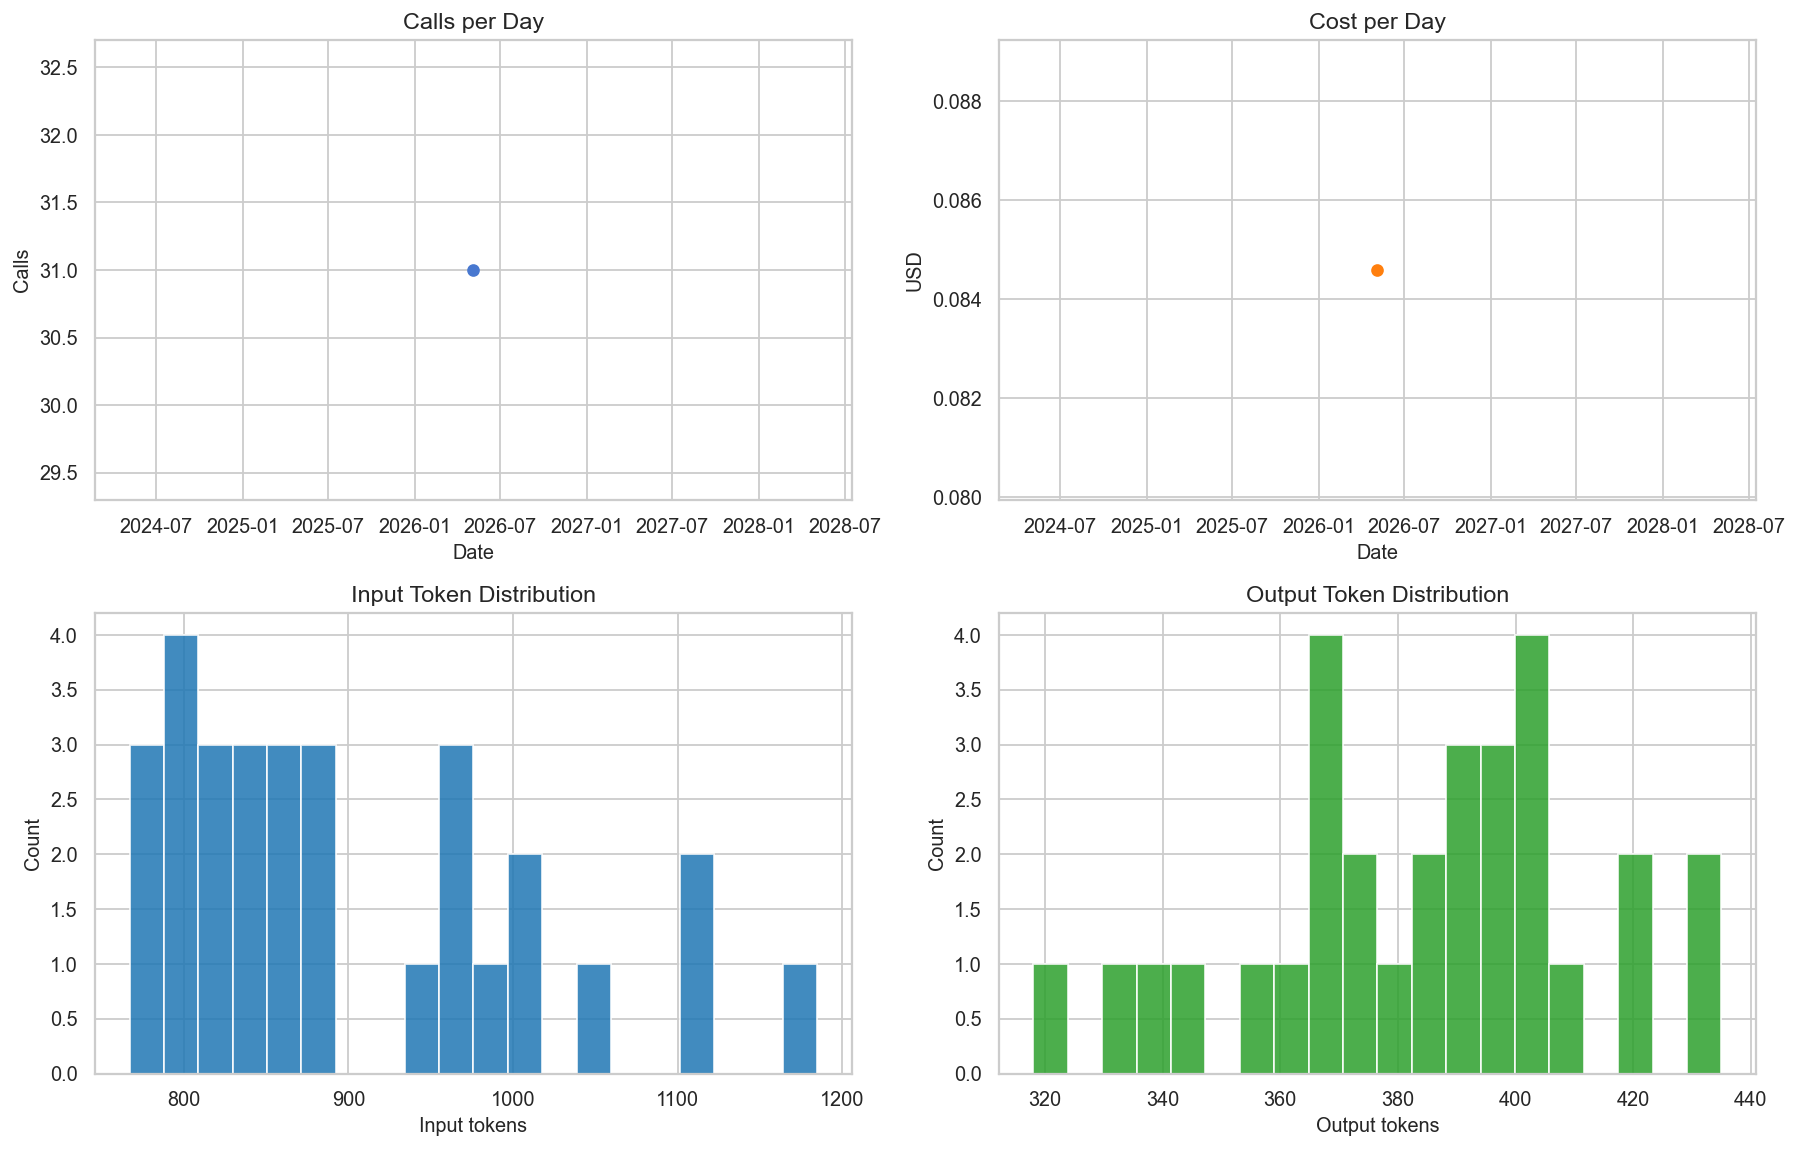

In [8]:
plot_df = df.sort_values('timestamp').copy()
plot_df['date'] = plot_df['timestamp'].dt.date

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

daily = plot_df.groupby('date').agg(
    calls=('timestamp', 'count'),
    cost=('total_cost_usd', 'sum'),
    input_tokens=('input_tokens', 'sum'),
    output_tokens=('output_tokens', 'sum'),
)
daily.index = pd.to_datetime(daily.index)

axes[0, 0].plot(daily.index, daily['calls'], marker='o')
axes[0, 0].set_title('Calls per Day')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Calls')

axes[0, 1].plot(daily.index, daily['cost'], marker='o', color='tab:orange')
axes[0, 1].set_title('Cost per Day')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('USD')

axes[1, 0].hist(plot_df.loc[~plot_df['is_error'], 'input_tokens'], bins=20, color='tab:blue', alpha=0.85)
axes[1, 0].set_title('Input Token Distribution')
axes[1, 0].set_xlabel('Input tokens')
axes[1, 0].set_ylabel('Count')

axes[1, 1].hist(plot_df.loc[~plot_df['is_error'], 'output_tokens'], bins=20, color='tab:green', alpha=0.85)
axes[1, 1].set_title('Output Token Distribution')
axes[1, 1].set_xlabel('Output tokens')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

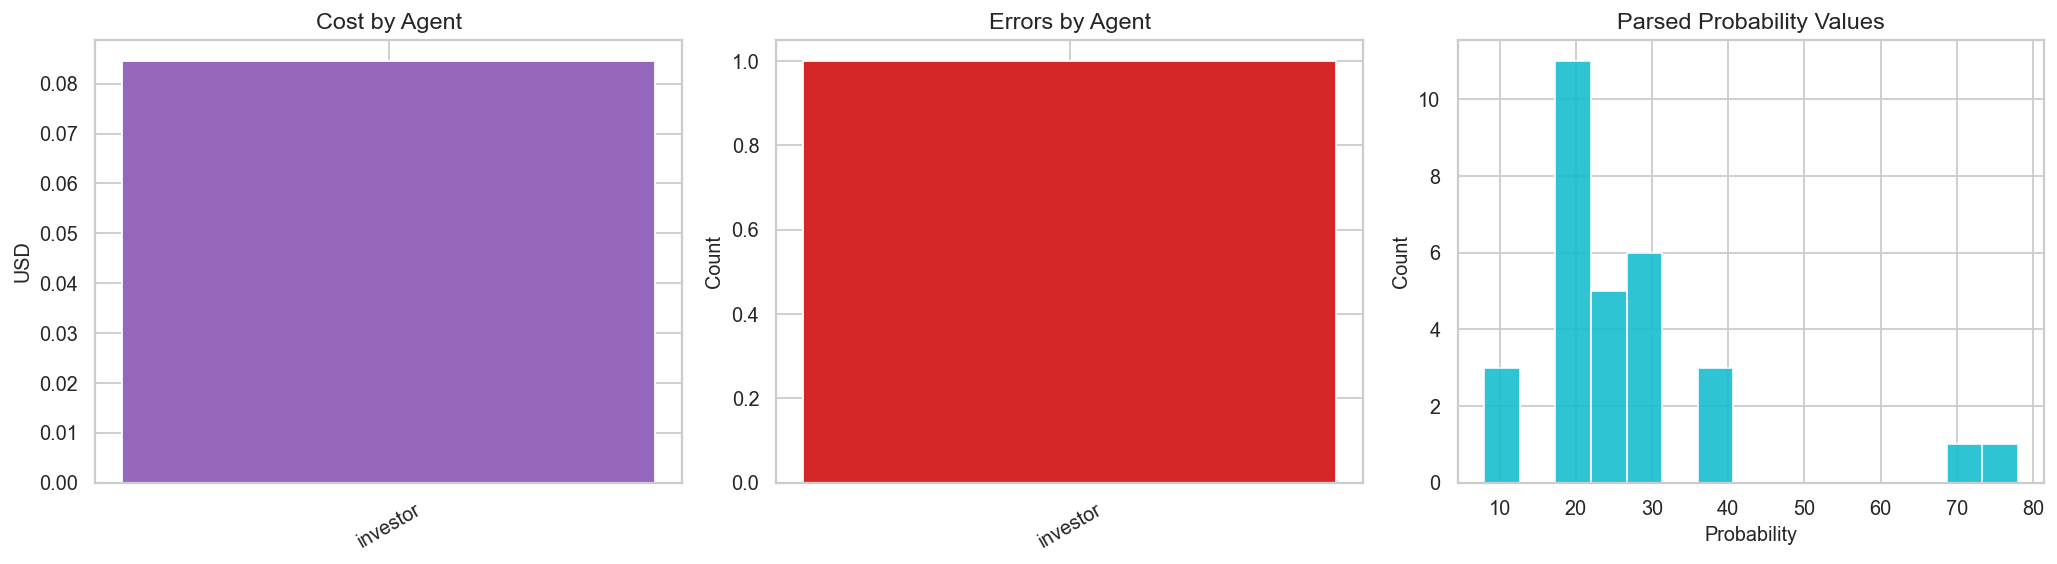

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

agent_costs = by_agent['total_cost_usd'].sort_values(ascending=False)
axes[0].bar(agent_costs.index.astype(str), agent_costs.values, color='tab:purple')
axes[0].set_title('Cost by Agent')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=30)

error_counts = df.groupby('agent_name')['is_error'].sum().sort_values(ascending=False)
axes[1].bar(error_counts.index.astype(str), error_counts.values, color='tab:red')
axes[1].set_title('Errors by Agent')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

valid_probs = df['probability'].dropna()
if len(valid_probs):
    axes[2].hist(valid_probs, bins=15, color='tab:cyan', alpha=0.9)
axes[2].set_title('Parsed Probability Values')
axes[2].set_xlabel('Probability')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Recent Calls and Output Inspection

Use this section to inspect raw prompts, model responses, and failure cases.

In [13]:
# Show the full reasoning for the 10 most recent call with a response, if available
most_recent_response = df.loc[df['has_response']].sort_values('timestamp', ascending=False).head(10)
if not most_recent_response.empty:
    for _, row in most_recent_response.iterrows():
        full_response = row['assistant_response']
        print(f"\nMost Recent Assistant Response (full):")
        print(full_response)


Most Recent Assistant Response (full):
```json
{
  "decision": "PASS",
  "probability": 18,
  "market_assessment": "Content curation and personalized news aggregation is a crowded, low-margin sector with limited differentiation and weak exit potential.",
  "team_assessment": "Minimal team of 3 with no recorded university credentials or top-tier educational background signals weak human capital and limited domain expertise.",
  "funding_assessment": "Only $110k raised across a single round by 2013 suggests difficulty attracting investor confidence; minimal external validation for a 6-year-old company.",
  "key_risks": [
    "Vague value proposition with no clear differentiation from established competitors (Google News, Flipboard, Pulse, etc.)",
    "Severely underfunded relative to well-capitalized competitors in the same space",
    "No team credentials or demonstrated domain expertise in machine learning, editorial, or product",
    "Minimal traction signals (only 1 milestone, 3 rel

## 4. Next Steps

- Filter `agent_name` to compare investor vs judge calls.
- Compare real runs against offline smoke-test logs.
- Extend the notebook with response parsing or prompt-drift checks if needed.